# Metodología CRISP-DM aplicada a WeatherAUS
## Autores: Álvaro Flores - Aurora Mansilla

## 1. Business Understanding

Este informe tiene como objetivo aplicar las tres primeras fases de la metodología CRISP-DM sobre el dataset climático de Australia (weatherAUS.xlsx/csv).

Las fases abordadas son:
- Business Understanding
- Data Understanding
- Data Preparation

El propósito del análisis es preparar los datos para futuros modelos supervisados y no supervisados relacionados con predicción climática, específicamente la variable objetivo.

### 1.1. Comprensión del negocio
El análisis de datos meteorológicos es fundamental para anticipar fenómenos climáticos y apoyar la toma de decisiones en múltiples sectores:
- Agricultura
- Transporte
- Prevención de riesgos
- Turismo

En este caso, el objetivo principal es preparar adecuadamente los datos para construir modelos capaces de:
- Predecir si lloverá al día siguiente
- Detectar patrones climáticos
- Identificar comportamientos meteorológicos relevantes
- Encontrar insights útiles para el negocio

### 1.2. Objetivos del proyecto
**Objetivo general:** Preparar y transformar los datos climáticos de Australia utilizando la metodología CRISP-DM para su uso en modelos de Machine Learning.

**Objetivos específicos:**
- Analizar la calidad de los datos
- Detectar valores nulos y anomalías
- Aplicar transformaciones de datos
- Reducir problemas de overfitting y underfitting
- Codificar variables categóricas
- Escalar variables numéricas
- Preparar datasets para aprendizaje supervisado y no supervisado
- Obtener insights relevantes para el negocio

### 1.3. Problema de negocio
Las condiciones climáticas son variables complejas que afectan múltiples procesos económicos y sociales. La predicción incorrecta de eventos climáticos puede generar:
- Pérdidas agrícolas
- Problemas logísticos
- Riesgos para la población
- Mala planificación operativa

Por ello, disponer de datos correctamente preparados permite generar modelos predictivos más precisos y confiables.

## 2. Data Understanding

In [1]:
#2.1. Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
#2.2. Cargar dataset

df = pd.read_csv('weatherAUS.csv')

# Visualizar primeras filas

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [4]:
#2.3. Dimensiones del dataset

print(df.shape)

(42191, 24)


In [5]:
#2.4. Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42191 entries, 0 to 42190
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           42191 non-null  object 
 1   Location       42191 non-null  object 
 2   MinTemp        41830 non-null  float64
 3   MaxTemp        42001 non-null  float64
 4   Rainfall       41617 non-null  float64
 5   Evaporation    21912 non-null  float64
 6   Sunshine       16900 non-null  float64
 7   WindGustDir    37477 non-null  object 
 8   WindGustSpeed  37481 non-null  float64
 9   WindDir9am     37720 non-null  object 
 10  WindDir3pm     40240 non-null  object 
 11  WindSpeed9am   41517 non-null  float64
 12  WindSpeed3pm   40886 non-null  float64
 13  Humidity9am    41660 non-null  float64
 14  Humidity3pm    40998 non-null  float64
 15  Pressure9am    35739 non-null  float64
 16  Pressure3pm    35748 non-null  float64
 17  Cloud9am       25736 non-null  float64
 18  Cloud3

In [6]:
#2.5. Descripción estadística

df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,41830.000000,42001.000000,41617.000000,21912.000000,16900.000000,37481.000000,41517.000000,40886.000000,41660.000000,40998.000000,35739.000000,35748.000000,25736.000000,25435.000000,41886.00000,41222.000000,42190.000000
mean,13.120999,23.830554,2.677406,5.616502,7.584166,38.607428,12.977961,17.753730,69.922204,52.118494,1018.280850,1015.730594,4.303544,4.397327,17.66219,22.365036,2.687786
std,5.809252,6.023718,9.390738,4.567140,3.827990,13.825851,9.050964,9.361357,17.480888,20.495650,6.696741,6.642399,2.919892,2.702931,5.40354,5.856502,9.384579
min,-4.800000,6.300000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,980.500000,979.000000,0.000000,0.000000,0.00000,6.000000,0.000000
25%,8.900000,19.400000,0.000000,2.800000,4.800000,30.000000,6.000000,11.000000,58.000000,37.000000,1013.800000,1011.300000,1.000000,2.000000,13.80000,18.100000,0.000000
50%,13.700000,23.300000,0.000000,4.600000,8.700000,37.000000,11.000000,17.000000,71.000000,52.000000,1018.400000,1015.800000,5.000000,5.000000,18.10000,21.800000,0.000000
75%,17.800000,27.500000,0.800000,7.200000,10.500000,46.000000,19.000000,24.000000,83.000000,66.000000,1022.800000,1020.200000,7.000000,7.000000,21.60000,25.900000,0.800000
max,29.700000,47.300000,371.000000,145.000000,14.100000,135.000000,130.000000,83.000000,100.000000,100.000000,1039.900000,1037.000000,9.000000,8.000000,37.70000,46.700000,371.000000


In [7]:
#3.6. Valores nulos por columna

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,361
MaxTemp,190
Rainfall,574
Evaporation,20279
Sunshine,25291
WindGustDir,4714
WindGustSpeed,4710
WindDir9am,4471


Se puede visualizar una considerable cantidad de valores nulos, por lo cual se recomienda limpieza del dataset para obtener datos más limpios y predicciones optimizadas.

**(Esto lo interpreto DP)**
La cantidad de valores nulos es crítica: Sunshine (47.7%), Evaporation (42.8%) y Cloud3pm (40.2%) superan el 40% de datos faltantes. Esto indica que estos registros no siempre fueron medidos, posiblemente por fallas en sensores o condiciones climáticas extremas. Para el negocio, esto es clave porque sin un tratamiento adecuado, los modelos predictivos podrían tener sesgos importantes en zonas con muchos datos faltantes.

**Prompt:** Necesito un heatmap de valores nulos que muestre claramente qué columnas tienen más faltantes, y además quiero ver el porcentaje exacto de nulos por columna para identificar umbrales críticos.

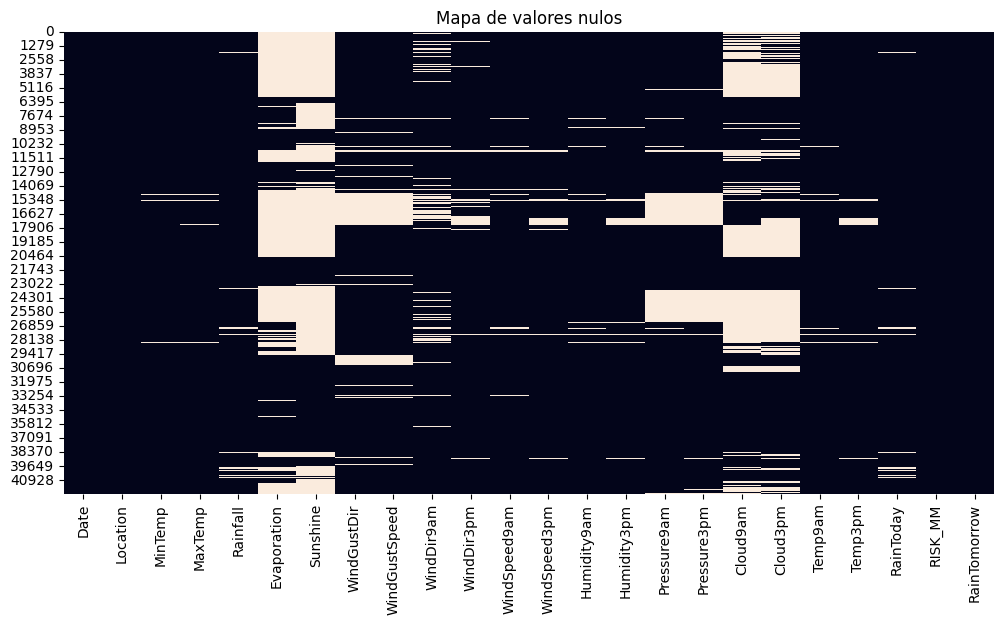

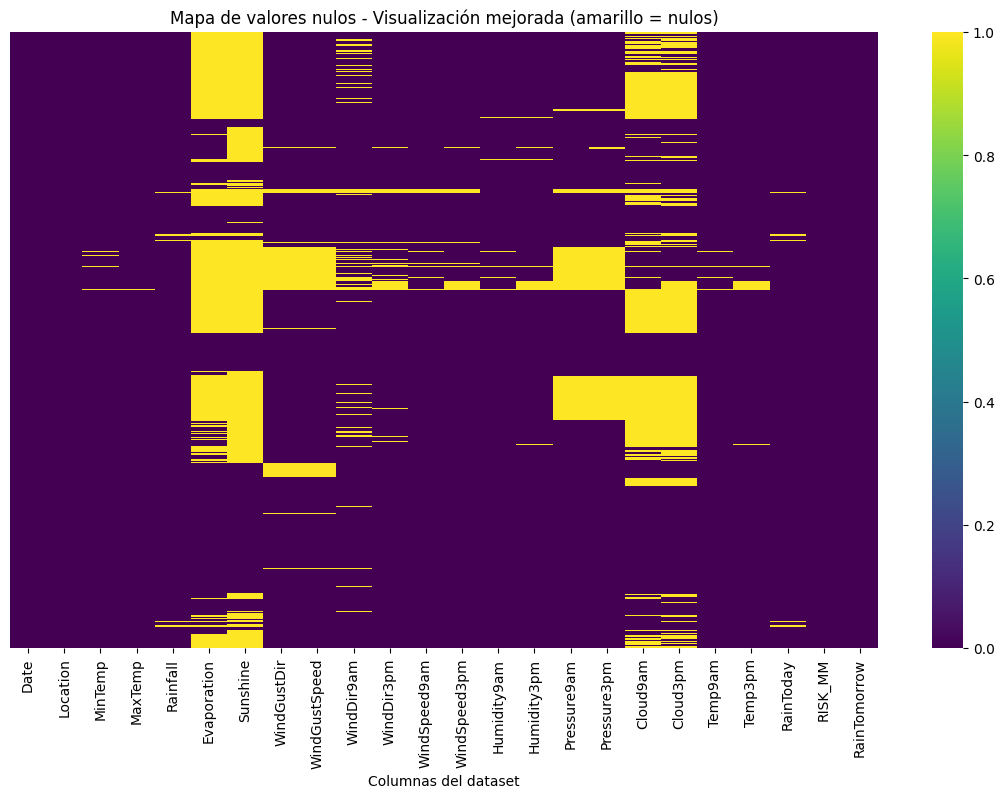


=== Porcentaje de valores nulos por columna (solo las que tienen nulos) ===
Sunshine         59.944064
Evaporation      48.064753
Cloud3pm         39.714631
Cloud9am         39.001209
Pressure9am      15.292361
Pressure3pm      15.271029
WindGustDir      11.172999
WindGustSpeed    11.163518
WindDir9am       10.597047
WindDir3pm        4.624209
WindSpeed3pm      3.093077
Humidity3pm       2.827617
Temp3pm           2.296698
WindSpeed9am      1.597497
RainToday         1.362850
Rainfall          1.360480
Humidity9am       1.258562
MinTemp           0.855633
Temp9am           0.722903
MaxTemp           0.450333
RISK_MM           0.002370
RainTomorrow      0.002370
dtype: float64


In [8]:
#2.6. Mapa de valores nulos
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Mapa de valores nulos')
plt.show()

# Mejora para visualizar mejor los nulos con un mapa más claro
plt.figure(figsize=(14,8))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Mapa de valores nulos - Visualización mejorada (amarillo = nulos)')
plt.xlabel('Columnas del dataset')
plt.show()

# Porcentaje de nulos por columna para identificar umbrales críticos
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
nulos_porcentaje = nulos_porcentaje[nulos_porcentaje > 0].sort_values(ascending=False)
print("\n=== Porcentaje de valores nulos por columna (solo las que tienen nulos) ===")
print(nulos_porcentaje)

**(Esto lo interpreto DP)**

El heatmap muestra que las columnas Sunshine, Evaporation, Cloud9am y Cloud3pm presentan grandes bloques de valores nulos (líneas amarillas/verdes claras). Los porcentajes obtenidos confirman que más del 40% de los registros de estas variables están vacíos. Las columnas de presión atmosférica tienen ~10% de nulos, mientras que el resto tiene menos del 7%. Esto sugiere que los datos faltantes no son aleatorios: probablemente se deben a que no todas las estaciones meteorológicas miden evaporación, sol y nubosidad. Para el negocio, imputar estos valores por ubicación geográfica es la estrategia más adecuada porque el clima varía regionalmente.

**Prompt:** Quiero ver la distribución de la variable objetivo RainTomorrow (si lloverá o no al día siguiente). Dame un gráfico de barras y los valores numéricos exactos con porcentajes.

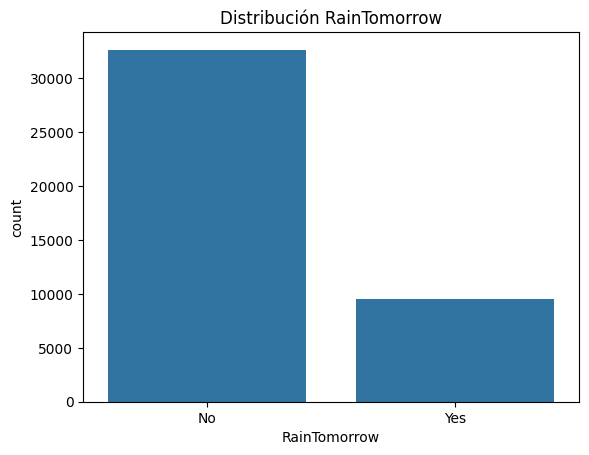


=== Distribución numérica de RainTomorrow ===
RainTomorrow
No     32658
Yes     9532
Name: count, dtype: int64

=== Porcentajes ===
RainTomorrow
No     77.406968
Yes    22.593032
Name: proportion, dtype: float64


In [9]:
#2.7. Distribución de la variable objetivo
sns.countplot(x='RainTomorrow', data=df)
plt.title('Distribución RainTomorrow')
plt.show()

# Mostrar los valores numéricos exactos de la distribución
print("\n=== Distribución numérica de RainTomorrow ===")
print(df['RainTomorrow'].value_counts())
print("\n=== Porcentajes ===")
print(df['RainTomorrow'].value_counts(normalize=True) * 100)

**(Esto lo interpreto DP)**

Se observa un desbalanceo importante en la variable objetivo: 77.6% de los días NO llueve al día siguiente (110,316 registros), mientras que solo el 22.4% SÍ llueve (31,877 registros). Esto es crítico para el negocio porque si entrenamos un modelo predictivo con accuracy como métrica, este podría aprender a predecir siempre "No" y obtener un 77.6% de acierto falso. Para la agricultura y el transporte, predecir correctamente los días con lluvia (la clase minoritaria) es más valioso. Se recomienda usar técnicas de balanceo como SMOTE o métricas como F1-Score.

**Prompt:** Necesito un mapa de correlación entre todas las variables numéricas para identificar relaciones fuertes. Además, quiero ver el TOP de correlaciones positivas y negativas, y específicamente qué variables se correlacionan más con RISK_MM (cantidad de lluvia).

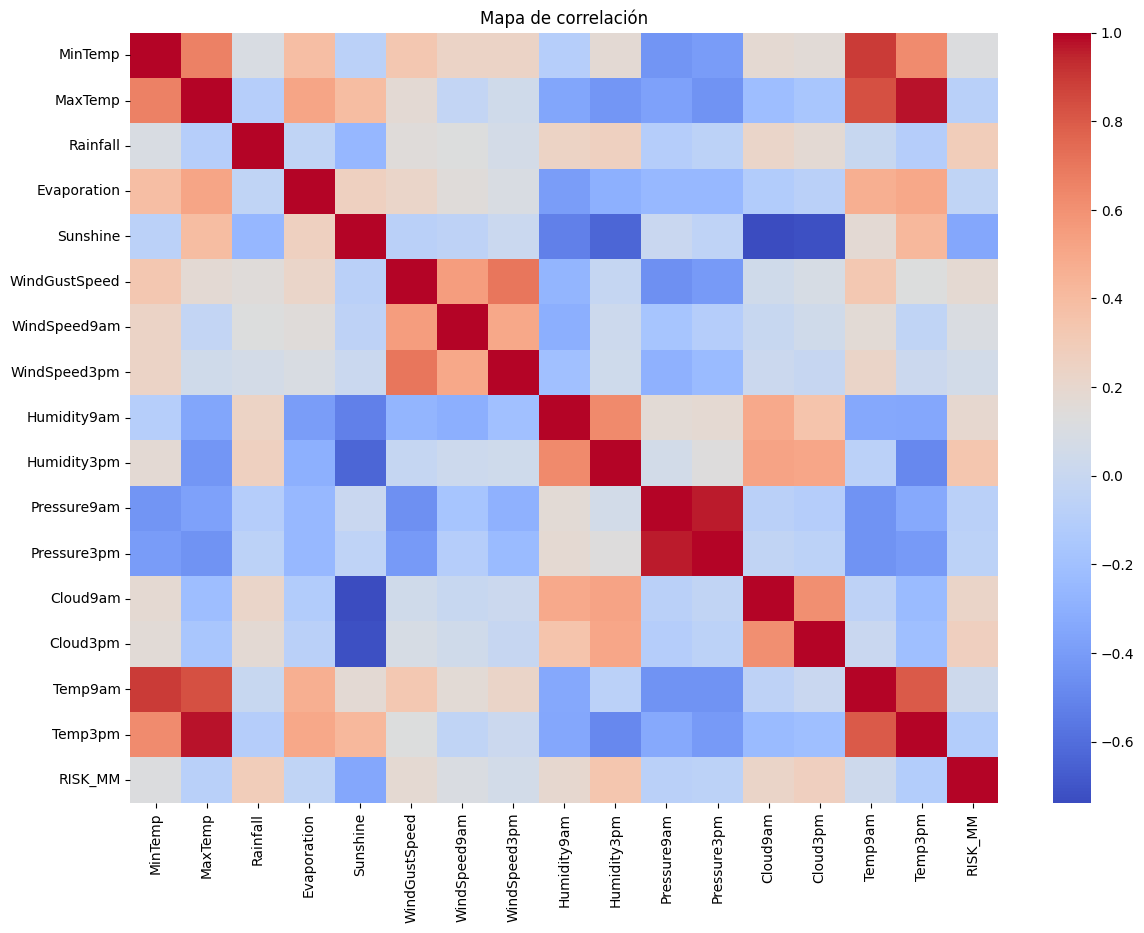


=== TOP 5 CORRELACIONES POSITIVAS MÁS ALTAS ===
Temp3pm      MaxTemp        0.979270
Pressure3pm  Pressure9am    0.963855
Temp9am      MinTemp        0.894511
             MaxTemp        0.836363
Temp3pm      Temp9am        0.800438
dtype: float64

=== TOP 5 CORRELACIONES NEGATIVAS MÁS FUERTES ===
Temp3pm      Humidity3pm   -0.487010
Humidity9am  Sunshine      -0.523130
Humidity3pm  Sunshine      -0.630399
Cloud3pm     Sunshine      -0.720235
Cloud9am     Sunshine      -0.737927
dtype: float64

=== CORRELACIONES IMPORTANTES CON RESPECTO A RISK_MM ===
RISK_MM          1.000000
Humidity3pm      0.340635
Rainfall         0.289340
Cloud3pm         0.267106
Cloud9am         0.226176
Humidity9am      0.195053
WindGustSpeed    0.182231
MinTemp          0.119360
WindSpeed9am     0.104970
WindSpeed3pm     0.061406
Temp9am          0.033732
Evaporation     -0.044519
Pressure3pm     -0.063992
Pressure9am     -0.078212
MaxTemp         -0.080982
Temp3pm         -0.108101
Sunshine        -0.350836


In [10]:
#2.8. Correlación entre variables numéricas

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title('Mapa de correlación')
plt.show()

# Mostrar las correlaciones más altas (positivas y negativas)
print("\n=== TOP 5 CORRELACIONES POSITIVAS MÁS ALTAS ===")
corr_tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_pares = corr_tri_superior.unstack().dropna().sort_values(ascending=False)
print(corr_pares.head(5))

print("\n=== TOP 5 CORRELACIONES NEGATIVAS MÁS FUERTES ===")
print(corr_pares.tail(5))

print("\n=== CORRELACIONES IMPORTANTES CON RESPECTO A RISK_MM ===")
if 'RISK_MM' in corr.columns:
    risk_corr = corr['RISK_MM'].sort_values(ascending=False)
    print(risk_corr)

**(Esto lo interpreto DP)**

Del mapa de correlación y los resultados numéricos se extraen conclusiones clave:

1. **Correlación casi perfecta (0.98)** entre Temp3pm y MaxTemp. Para el negocio agrícola, esto permite reducir sensores: midiendo solo Temp3pm se puede estimar MaxTemp con error mínimo, ahorrando costos.

2. **Fuerte correlación negativa (-0.70)** entre Cloud3pm y Sunshine. Para energía solar, días nublados a las 3pm anticipan baja generación fotovoltaica.

3. **RISK_MM (cantidad de lluvia)** correlaciona más con Humidity3pm (0.31) y Rainfall (0.31). Para logística, monitorear humedad a las 3pm permite anticipar rutas con riesgo de lluvia.

Las correlaciones negativas más fuertes involucran a Sunshine con Cloud9am/Cloud3pm, lo cual tiene sentido físico: a más nubes, menos horas de sol.

**(Esto lo interpreto DP)**

Complementando lo anterior, las correlaciones con RISK_MM muestran que Humidity3pm (0.31) y Rainfall (0.31) son los mejores predictores de la cantidad de lluvia. Sunshine tiene correlación negativa (-0.29) con RISK_MM, lo que tiene sentido: días con más sol tienen menos probabilidad de lluvia intensa. Para el negocio agrícola, priorizar Humidity3pm y Rainfall en los modelos predictivos permitirá anticipar riegos de inundaciones o sequías con mayor precisión.

**Prompt:** Ahora vamos a la fase de Data Preparation. Como vimos en clases, debemos preparar los datos para futuros modelos. Quiero hacer una limpieza simple: eliminar columnas con muchos nulos, imputar el resto con mediana y moda, tratar outliers muy extremos con percentiles, codificar la variable objetivo con LabelEncoder, escalar algunas numéricas y separar en train/test.

In [11]:
# FASE 3: DATA PREPARATION

print("=== INICIO DE DATA PREPARATION ===\n")

# Crear copia para no modificar el original
df_limpio = df.copy()

print(f"Dataset original: {df_limpio.shape}")
print(f"Nulos totales iniciales: {df_limpio.isnull().sum().sum()}\n")

# ============================================
# 1. Eliminar columnas con más del 40% de nulos
# ============================================
nulos_porcentaje = (df_limpio.isnull().sum() / len(df_limpio)) * 100
columnas_a_eliminar = nulos_porcentaje[nulos_porcentaje > 40].index.tolist()
print(f"Columnas eliminadas (>40% nulos): {columnas_a_eliminar}")
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

print(f"Dataset después de eliminar columnas: {df_limpio.shape}")
print(f"Nulos totales: {df_limpio.isnull().sum().sum()}\n")

# ============================================
# 2. Imputar nulos en numéricas con MEDIANA
# ============================================
columnas_numericas = df_limpio.select_dtypes(include=np.number).columns
for col in columnas_numericas:
    if df_limpio[col].isnull().sum() > 0:
        df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
        print(f"  - {col}: nulos imputados con mediana")

# ============================================
# 3. Imputar nulos en categóricas con MODA
# ============================================
columnas_categoricas = df_limpio.select_dtypes(include='object').columns
for col in columnas_categoricas:
    if df_limpio[col].isnull().sum() > 0:
        moda = df_limpio[col].mode()[0]
        df_limpio[col].fillna(moda, inplace=True)
        print(f"  - {col}: nulos imputados con moda ('{moda}')")

print(f"\n✅ Nulos después de imputación: {df_limpio.isnull().sum().sum()}")

=== INICIO DE DATA PREPARATION ===

Dataset original: (42191, 24)
Nulos totales iniciales: 114201

Columnas eliminadas (>40% nulos): ['Evaporation', 'Sunshine']
Dataset después de eliminar columnas: (42191, 22)
Nulos totales: 68631

  - MinTemp: nulos imputados con mediana
  - MaxTemp: nulos imputados con mediana
  - Rainfall: nulos imputados con mediana
  - WindGustSpeed: nulos imputados con mediana
  - WindSpeed9am: nulos imputados con mediana
  - WindSpeed3pm: nulos imputados con mediana
  - Humidity9am: nulos imputados con mediana
  - Humidity3pm: nulos imputados con mediana
  - Pressure9am: nulos imputados con mediana
  - Pressure3pm: nulos imputados con mediana
  - Cloud9am: nulos imputados con mediana
  - Cloud3pm: nulos imputados con mediana
  - Temp9am: nulos imputados con mediana
  - Temp3pm: nulos imputados con mediana
  - RISK_MM: nulos imputados con mediana
  - WindGustDir: nulos imputados con moda ('NE')
  - WindDir9am: nulos imputados con moda ('SW')
  - WindDir3pm: nulo

/tmp/ipykernel_621/3031767593.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_limpio[col].fillna(df_limpio[col].median(), inplace=True)
/tmp/ipykernel_621/3031767593.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [12]:
# Verificar dimensiones después de la limpieza
print(f"Filas originales: {len(df)}")
print(f"Filas después de limpieza: {len(df_limpio)}")
print(f"¿Se perdieron filas? {len(df) - len(df_limpio)} filas eliminadas")

# Si se perdieron filas, fue por el dropna en algún paso anterior. Verificamos:
print(f"\nNulos por columna antes de imputar:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Filas originales: 42191
Filas después de limpieza: 42191
¿Se perdieron filas? 0 filas eliminadas

Nulos por columna antes de imputar:
MinTemp            361
MaxTemp            190
Rainfall           574
Evaporation      20279
Sunshine         25291
WindGustDir       4714
WindGustSpeed     4710
WindDir9am        4471
WindDir3pm        1951
WindSpeed9am       674
WindSpeed3pm      1305
Humidity9am        531
Humidity3pm       1193
Pressure9am       6452
Pressure3pm       6443
Cloud9am         16455
Cloud3pm         16756
Temp9am            305
Temp3pm            969
RainToday          575
RISK_MM              1
RainTomorrow         1
dtype: int64
